# 05 — Embedding linker (Method B) grid-search tuning

Grid-search `EmbeddingLinker`'s four knobs (`table_top_k`, `table_threshold`, `column_top_k`, `column_threshold`) on the **same 1000-example seeded subset of Spider train** (`seed=42`) used for the lexical tuning, scored against **sqlglot-derived Tier-2 gold** (train has no Taniguchi annotations, so Tier-2 is the honest match for train tuning).

Grid (locked, 4 x 5 x 4 x 5 = 400 configurations — do not expand without explicit approval):

| Knob | Values |
| --- | --- |
| `table_top_k` | 1, 2, 3, 5 |
| `table_threshold` | 0.30, 0.40, 0.50, 0.60, 0.70 |
| `column_top_k` | 3, 5, 8, 12 |
| `column_threshold` | 0.30, 0.40, 0.50, 0.60, 0.70 |

Selection rule: argmax `mean_f1 = (table_f1 + column_f1) / 2` (macro), ties broken by higher `mean_recall`.

Kept fast (well under 5 min on CPU) because schema embeddings are disk-cached, question embeddings are encoded once, and the full similarity matrix is precomputed once — each of the 400 configs only re-applies a top-k/threshold mask to that matrix.

Outputs:
1. Sweep DataFrame (top 20 rows saved to `outputs/results/embedding_sweep.csv`).
2. Column-grid heatmaps (`mean_f1` for `column_top_k` x `column_threshold`), one panel per `table_top_k` value, at the winning `table_threshold`.
3. Chosen config written to `config.yaml` at `embedding.tuned`.

This notebook is transient — production logic lives in `src/schema_linking/utils/tuning.py`.


In [1]:
import random
import re
import sys
import time
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / 'src'))

from schema_linking.data_loader import load_spider_questions
from schema_linking.gold_link_extractor import extract_tier2_all
from schema_linking.schema_parser import load_schemas
from schema_linking.utils.config import load_config
from schema_linking.utils.embeddings import SchemaEncoder
from schema_linking.utils.tuning import (
    COLUMN_THRESHOLD_GRID,
    COLUMN_TOP_K_GRID,
    TABLE_THRESHOLD_GRID,
    TABLE_TOP_K_GRID,
    tune_embedding,
)

SEED = 42
SUBSET_SIZE = 1000
RESULTS_DIR = REPO_ROOT / 'outputs' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
schemas = load_schemas()
train_all = load_spider_questions('train')
rng = random.Random(SEED)
subset = rng.sample(list(train_all), SUBSET_SIZE)
print(f'schemas: {len(schemas)} dbs, train: {len(train_all)} examples, subset: {len(subset)}')


schemas: 166 dbs, train: 7000 examples, subset: 1000


In [3]:
gold_links = extract_tier2_all(subset, schemas)
gold = {
    qid: {
        'db_id': gl.db_id,
        'tables': list(gl.tables),
        'columns': [list(c) for c in gl.columns],
    }
    for qid, gl in gold_links.items()
}
subset_with_gold = [ex for ex in subset if ex.question_id in gold]
needed_schemas = {ex.db_id: schemas[ex.db_id] for ex in subset_with_gold}
print(f'Tier-2 gold extracted for {len(gold)}/{len(subset)} examples, {len(needed_schemas)} distinct dbs touched')


column 'Le Pop' unresolvable in db 'music_2' (qid 5238) — skipping
column 'Dayana Robel' unresolvable in db 'insurance_fnol' (qid 912) — skipping
column '%Alex%' unresolvable in db 'customers_and_addresses' (qid 6074) — skipping
column 'Japan' unresolvable in db 'film_rank' (qid 4139) — skipping
column 'A4' unresolvable in db 'store_product' (qid 4931) — skipping
column 'PUR' unresolvable in db 'tracking_share_transactions' (qid 5865) — skipping
column 'Janessa' unresolvable in db 'driving_school' (qid 6630) — skipping
column 'Sawayn' unresolvable in db 'driving_school' (qid 6630) — skipping
column 'Rachel Elnaugh' unresolvable in db 'entrepreneur' (qid 2276) — skipping
column 'Fanny' unresolvable in db 'behavior_monitoring' (qid 3112) — skipping
column 'food' unresolvable in db 'tracking_orders' (qid 6942) — skipping
column 'Collectible card game' unresolvable in db 'game_1' (qid 5977) — skipping
column 'Aerosmith' unresolvable in db 'store_1' (qid 569) — skipping
column 'Colorado' un

Tier-2 gold extracted for 1000/1000 examples, 138 distinct dbs touched


In [4]:
config = load_config()
encoder = SchemaEncoder(
    model_name=config.embedding.model_name,
    revision=config.embedding.revision,
    cache_dir=config.embedding.cache_dir,
)
print(f'encoder: {encoder.model_name} @ {encoder.revision[:12]} (dim={encoder.dim})')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

encoder: BAAI/bge-small-en-v1.5 @ 5c38ec7c405e (dim=384)


In [5]:
start = time.perf_counter()
best, sweep = tune_embedding(
    examples=subset_with_gold,
    gold=gold,
    schemas=needed_schemas,
    encoder=encoder,
    gold_tier='all_sql_used',
)
elapsed = time.perf_counter() - start
print(f'{len(sweep)} configurations swept in {elapsed:.1f}s')
print('CHOSEN config:', best)
sweep.sort_values('mean_f1', ascending=False).head(10)


400 configurations swept in 17.6s
CHOSEN config: {'table_top_k': 2, 'table_threshold': 0.5, 'column_top_k': 3, 'column_threshold': 0.6}


,table_top_k,table_threshold,column_top_k,column_threshold,table_precision,table_recall,table_f1,column_precision,column_recall,column_f1,mean_f1,mean_recall
143,2,0.5,3,0.6,0.657,0.814900,0.692905,0.558833,0.688735,0.550020,0.621463,0.751818
142,2,0.5,3,0.5,0.657,0.814900,0.692905,0.544500,0.695508,0.549400,0.621153,0.755204
140,2,0.5,3,0.3,0.657,0.814900,0.692905,0.543667,0.695508,0.549067,0.620986,0.755204
141,2,0.5,3,0.4,0.657,0.814900,0.692905,0.543667,0.695508,0.549067,0.620986,0.755204
3,1,0.3,3,0.6,0.822,0.611200,0.675367,0.558833,0.688735,0.550020,0.612693,0.649968
23,1,0.4,3,0.6,0.822,0.611200,0.675367,0.558833,0.688735,0.550020,0.612693,0.649968
22,1,0.4,3,0.5,0.822,0.611200,0.675367,0.544500,0.695508,0.549400,0.612384,0.653354
2,1,0.3,3,0.5,0.822,0.611200,0.675367,0.544500,0.695508,0.549400,0.612384,0.653354
123,2,0.4,3,0.6,0.610,0.833067,0.674738,0.558833,0.688735,0.550020,0.612379,0.760901
1,1,0.3,3,0.4,0.822,0.611200,0.675367,0.543667,0.695508,0.549067,0.612217,0.653354


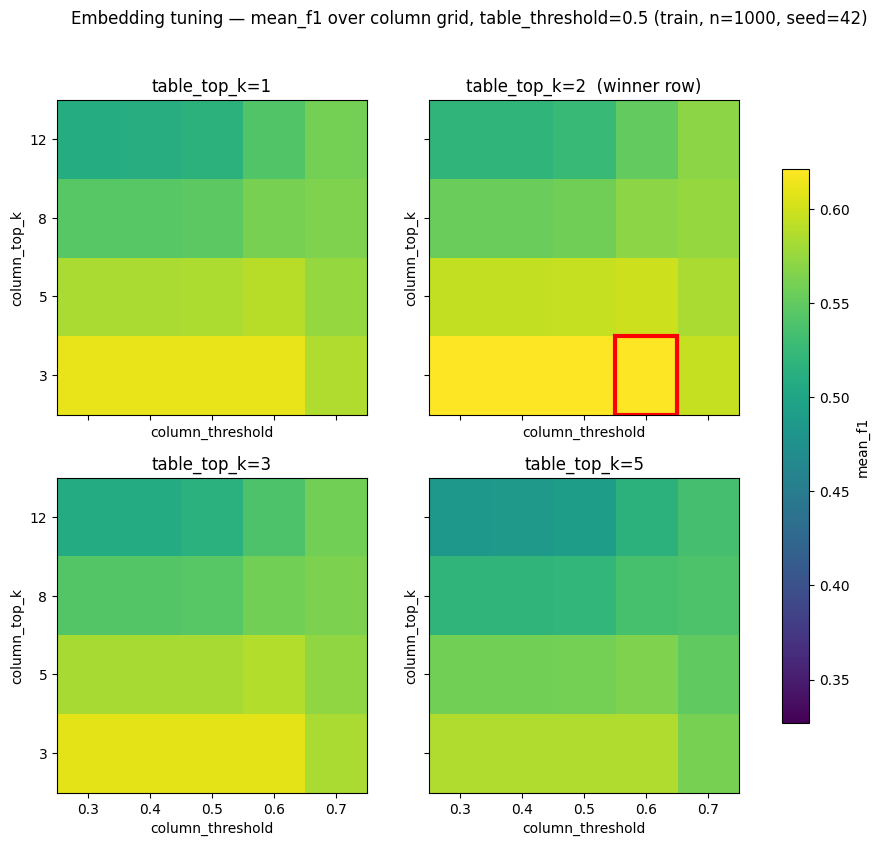

In [6]:
best_table_threshold = best['table_threshold']
fixed = sweep[np.isclose(sweep['table_threshold'], best_table_threshold)]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
vmin, vmax = sweep['mean_f1'].min(), sweep['mean_f1'].max()

im = None
for ax, table_top_k in zip(axes.flat, TABLE_TOP_K_GRID):
    panel = fixed[fixed['table_top_k'] == table_top_k]
    pivot = panel.pivot(index='column_top_k', columns='column_threshold', values='mean_f1')
    pivot = pivot.reindex(index=list(COLUMN_TOP_K_GRID), columns=list(COLUMN_THRESHOLD_GRID))
    im = ax.imshow(pivot.values, aspect='auto', vmin=vmin, vmax=vmax, cmap='viridis', origin='lower')
    ax.set_xticks(range(len(COLUMN_THRESHOLD_GRID)))
    ax.set_xticklabels(COLUMN_THRESHOLD_GRID)
    ax.set_yticks(range(len(COLUMN_TOP_K_GRID)))
    ax.set_yticklabels(COLUMN_TOP_K_GRID)
    ax.set_xlabel('column_threshold')
    ax.set_ylabel('column_top_k')
    title = f'table_top_k={table_top_k}'
    if table_top_k == best['table_top_k']:
        title += '  (winner row)'
        wi = list(COLUMN_TOP_K_GRID).index(best['column_top_k'])
        wj = list(COLUMN_THRESHOLD_GRID).index(best['column_threshold'])
        ax.add_patch(
            plt.Rectangle((wj - 0.5, wi - 0.5), 1, 1, fill=False, edgecolor='red', linewidth=3)
        )
    ax.set_title(title)

fig.suptitle(
    f'Embedding tuning — mean_f1 over column grid, table_threshold={best_table_threshold} '
    f'(train, n={len(subset_with_gold)}, seed={SEED})'
)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='mean_f1')
plt.savefig(RESULTS_DIR / 'embedding_tuning_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
print('WINNER:')
for k, v in best.items():
    print(f'  {k}: {v}')

winner_row = sweep.loc[
    (sweep['table_top_k'] == best['table_top_k'])
    & (sweep['table_threshold'] == best['table_threshold'])
    & (sweep['column_top_k'] == best['column_top_k'])
    & (sweep['column_threshold'] == best['column_threshold'])
].iloc[0]
winner_row


WINNER:
  table_top_k: 2
  table_threshold: 0.5
  column_top_k: 3
  column_threshold: 0.6


table_top_k         2.000000
table_threshold     0.500000
column_top_k        3.000000
column_threshold    0.600000
table_precision     0.657000
table_recall        0.814900
table_f1            0.692905
column_precision    0.558833
column_recall       0.688735
column_f1           0.550020
mean_f1             0.621463
mean_recall         0.751818
Name: 143, dtype: float64

In [8]:
cfg_path = REPO_ROOT / 'config.yaml'
with cfg_path.open(encoding='utf-8') as f:
    cfg_raw = yaml.safe_load(f) or {}
cfg_raw.setdefault('embedding', {})['tuned'] = {
    'table_top_k': int(best['table_top_k']),
    'table_threshold': float(best['table_threshold']),
    'column_top_k': int(best['column_top_k']),
    'column_threshold': float(best['column_threshold']),
}
with cfg_path.open('w', encoding='utf-8') as f:
    yaml.safe_dump(cfg_raw, f, sort_keys=False)
print(f'wrote embedding.tuned = {cfg_raw["embedding"]["tuned"]} to {cfg_path}')


wrote embedding.tuned = {'table_top_k': 2, 'table_threshold': 0.5, 'column_top_k': 3, 'column_threshold': 0.6} to /Users/mac/Documents/Masters BHT 2023-2025/Semester 6 2026 april-sep/code/config.yaml


In [9]:
top20 = sweep.sort_values(['mean_f1', 'mean_recall'], ascending=[False, False]).head(20)
top20.to_csv(RESULTS_DIR / 'embedding_sweep.csv', index=False)
print(f'wrote top 20 rows to {RESULTS_DIR / "embedding_sweep.csv"}')
top20


wrote top 20 rows to /Users/mac/Documents/Masters BHT 2023-2025/Semester 6 2026 april-sep/code/outputs/results/embedding_sweep.csv


,table_top_k,table_threshold,column_top_k,column_threshold,table_precision,table_recall,table_f1,column_precision,column_recall,column_f1,mean_f1,mean_recall
143,2,0.5,3,0.6,0.657,0.814900,0.692905,0.558833,0.688735,0.550020,0.621463,0.751818
142,2,0.5,3,0.5,0.657,0.814900,0.692905,0.544500,0.695508,0.549400,0.621153,0.755204
140,2,0.5,3,0.3,0.657,0.814900,0.692905,0.543667,0.695508,0.549067,0.620986,0.755204
141,2,0.5,3,0.4,0.657,0.814900,0.692905,0.543667,0.695508,0.549067,0.620986,0.755204
3,1,0.3,3,0.6,0.822,0.611200,0.675367,0.558833,0.688735,0.550020,0.612693,0.649968
23,1,0.4,3,0.6,0.822,0.611200,0.675367,0.558833,0.688735,0.550020,0.612693,0.649968
2,1,0.3,3,0.5,0.822,0.611200,0.675367,0.544500,0.695508,0.549400,0.612384,0.653354
22,1,0.4,3,0.5,0.822,0.611200,0.675367,0.544500,0.695508,0.549400,0.612384,0.653354
123,2,0.4,3,0.6,0.610,0.833067,0.674738,0.558833,0.688735,0.550020,0.612379,0.760901
0,1,0.3,3,0.3,0.822,0.611200,0.675367,0.543667,0.695508,0.549067,0.612217,0.653354
